# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Benedictus Ryu Gunawan | 5054251001|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from dataclasses import dataclass

@dataclass
class Config:
    SEED: int = 42
    ROOT_DIR: Path = Path(os.getcwd())
    DATA_DIR: Path = ROOT_DIR / "data"
    OUTPUT_DIR: Path = ROOT_DIR / "output"

cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Root directory: {cfg.ROOT_DIR}")
print(f"Data directory: {cfg.DATA_DIR}")
print(f"Output directory: {cfg.OUTPUT_DIR}")


Root directory: /home/ryz/data/collage/sem 3/ml/Modul-Praktikum-ML-RKA/2.Naive_Bayes,Logistic_Regression
Data directory: /home/ryz/data/collage/sem 3/ml/Modul-Praktikum-ML-RKA/2.Naive_Bayes,Logistic_Regression/data
Output directory: /home/ryz/data/collage/sem 3/ml/Modul-Praktikum-ML-RKA/2.Naive_Bayes,Logistic_Regression/output


In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv(cfg.DATA_DIR / "diabetes.csv")
display(df.head())

display(df.info())

display(df.describe())

print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"Jumlah missing (NaN): {int(df.isnull().sum().sum())}")
print(f"Jumlah baris duplikat: {int(df.duplicated().sum())}")


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Jumlah baris: 768
Jumlah kolom: 9
Jumlah missing (NaN): 0
Jumlah baris duplikat: 0


Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: count, dtype: float64


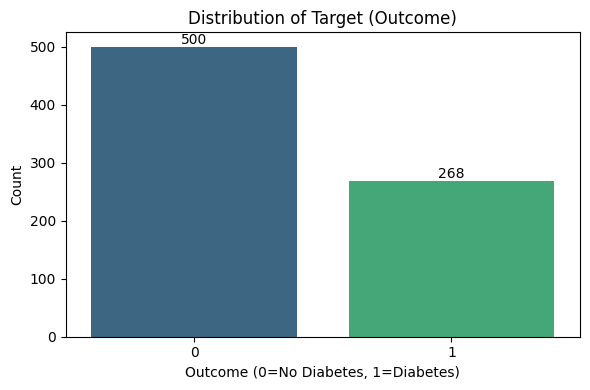

In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
# 0 = tidak diabetes, 1 = diabetes.

class_counts = df['Outcome'].value_counts().sort_index()
print(class_counts)
print(class_counts / len(df))

plt.figure(figsize=(6, 4))
plt.title("Distribution of Target (Outcome)")
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, hue=class_counts.index.astype(str), palette="viridis", legend=False)
for index, value in enumerate(class_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.xlabel("Outcome (0=No Diabetes, 1=Diabetes)")
plt.ylabel("Count")
plt.tight_layout()


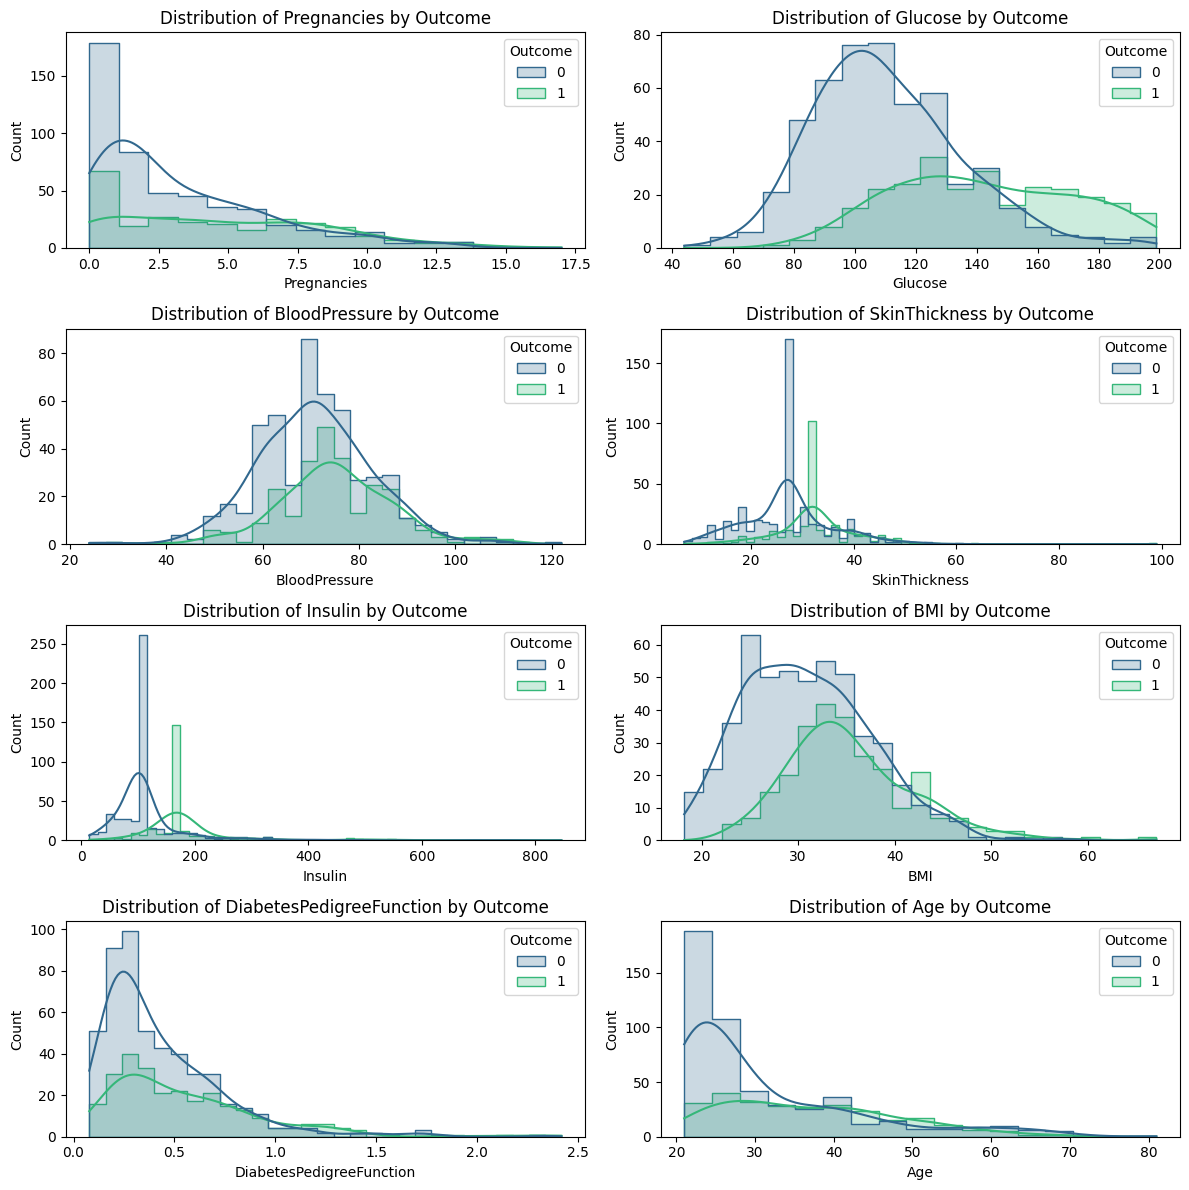

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.ravel()
for ax, col in zip(axes, features):
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, element='step', ax=ax, palette='viridis')
    ax.set_title(f"Distribution of {col} by Outcome")
plt.tight_layout()


Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


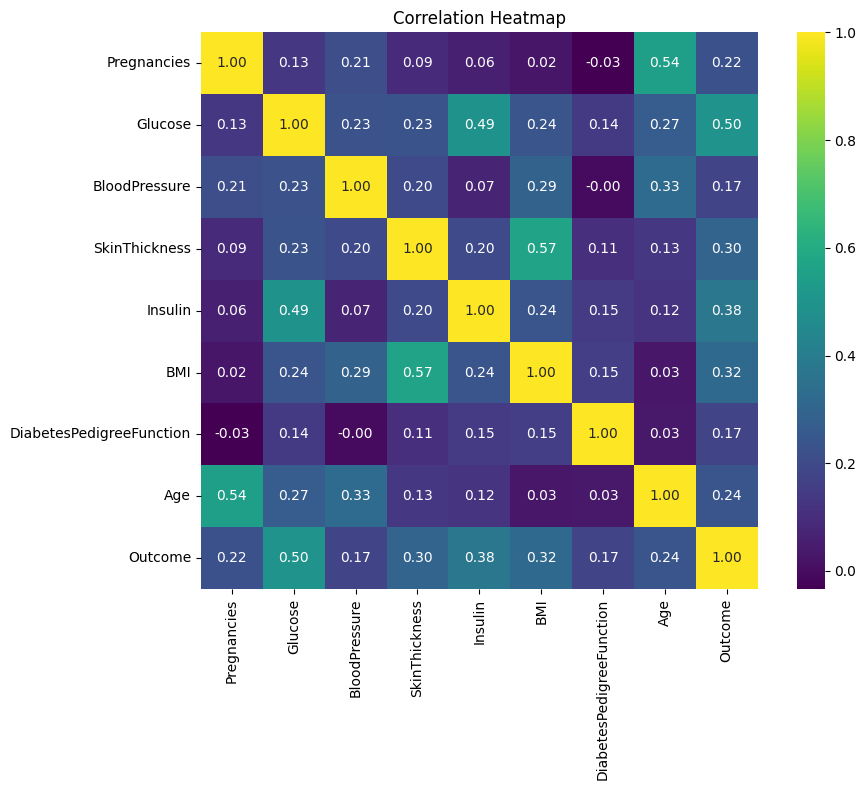

In [5]:
# Tampilkan heatmap korelasi antar fitur.
corr = df.corr(numeric_only=True)
print(corr['Outcome'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis', square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.622000,70.844000,27.170000,117.172000,30.846000,0.429734,31.190000
1,4.865672,142.302239,75.272388,32.671642,187.615672,35.398507,0.550500,37.067164


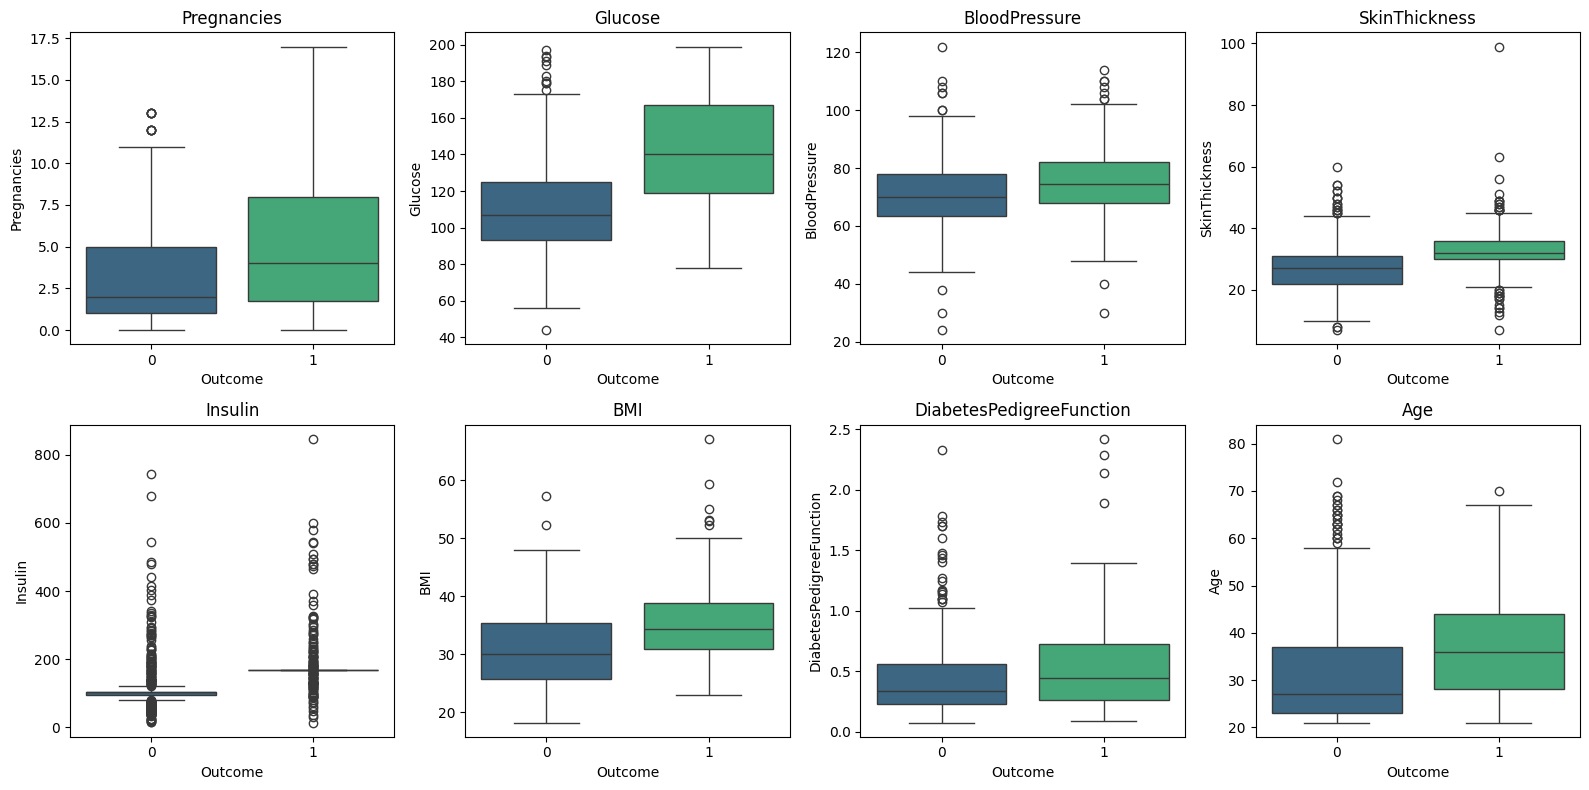

In [6]:
# EDA tambahan: rata-rata tiap fitur per kelas + boxplot untuk cek outlier/skew.
# Fitur dengan selisih rata-rata besar antar kelas (mis. Glucose) cenderung paling diskriminatif.
display(df.groupby('Outcome').mean(numeric_only=True))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, col in zip(axes, [c for c in df.columns if c != 'Outcome']):
    sns.boxplot(data=df, x='Outcome', y=col, hue='Outcome', palette='viridis', legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()


# 2. Preprocessing

In [7]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = (df[zero_cols] == 0).sum().sort_values(ascending=False)
print(zero_counts)
print(f"\nTotal nilai 0 pada 5 kolom tersebut: {int(zero_counts.sum())}")


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Total nilai 0 pada 5 kolom tersebut: 0


In [8]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

target = 'Outcome'

df_clean = df.copy()
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

print(f"Jumlah NaN setelah konversi 0->NaN: {int(df_clean.isnull().sum().sum())}")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


Jumlah NaN setelah konversi 0->NaN: 0
Series([], dtype: int64)


In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df_clean.drop(columns=[target])
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=cfg.SEED
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("Proporsi kelas train:")
print(y_train.value_counts(normalize=True))
print("Proporsi kelas test:")
print(y_test.value_counts(normalize=True))


X_train: (614, 8), X_test: (154, 8)
Proporsi kelas train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Proporsi kelas test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [ ]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_imp)
X_test_s = scaler.transform(X_test_imp)

print(f"X_train_s: {X_train_s.shape}, X_test_s: {X_test_s.shape}")
print(f"Median imputasi (fit pada train): {dict(zip(X.columns, imputer.statistics_.round(2)))}")
print(f"Mean train setelah scaling (harus ~= 0): {X_train_s.mean(axis=0).round(3)}")
print(f"Std train setelah scaling (harus ~= 1): {X_train_s.std(axis=0).round(3)}")


X_train_s: (614, 8), X_test_s: (154, 8)
Median imputasi (fit pada train): {'Pregnancies': np.float64(3.0), 'Glucose': np.float64(117.0), 'BloodPressure': np.float64(72.0), 'SkinThickness': np.float64(28.0), 'Insulin': np.float64(102.5), 'BMI': np.float64(32.4), 'DiabetesPedigreeFunction': np.float64(0.38), 'Age': np.float64(29.0)}
Mean train setelah scaling (harus ~= 0): [-0. -0.  0. -0.  0. -0. -0. -0.]
Std train setelah scaling (harus ~= 1): [1. 1. 1. 1. 1. 1. 1. 1.]


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [11]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
from sklearn.base import BaseEstimator
from typing import Any
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

@dataclass
class ModelEvaluation:
    model_name: str
    model: BaseEstimator
    accuracy: float
    precision: float
    recall: float
    f1_score: float
    y_test: Any = None
    y_pred: Any = None
    y_proba: Any = None

# NOTE: jangan memakai nama `eval` karena menimpa builtin Python `eval()`.
evaluations = []

model_gnb = GaussianNB()
model_gnb.fit(X_train_s, y_train)
print("GaussianNB berhasil dilatih.")


GaussianNB berhasil dilatih.


              precision    recall  f1-score   support

  NoDiabetes       0.80      0.77      0.79       100
    Diabetes       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



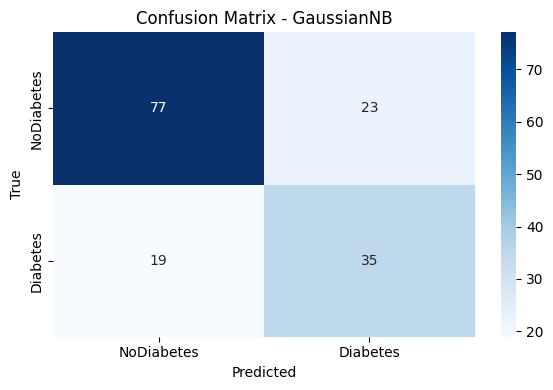

In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = model_gnb.predict(X_test_s)
y_proba_gnb = model_gnb.predict_proba(X_test_s)[:, 1]

evaluations.append(ModelEvaluation(
    model_name="GaussianNB",
    model=model_gnb,
    accuracy=accuracy_score(y_test, y_pred_gnb),
    precision=precision_score(y_test, y_pred_gnb),
    recall=recall_score(y_test, y_pred_gnb),
    f1_score=f1_score(y_test, y_pred_gnb),
    y_test=y_test,
    y_pred=y_pred_gnb,
    y_proba=y_proba_gnb,
))

print(classification_report(y_test, y_pred_gnb, target_names=['NoDiabetes', 'Diabetes']))
cm = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NoDiabetes', 'Diabetes'], yticklabels=['NoDiabetes', 'Diabetes'])
plt.title("Confusion Matrix - GaussianNB")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()


## 3.2 Logistic Regression

In [13]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
model_lr = LogisticRegression(max_iter=1000, random_state=cfg.SEED)
model_lr.fit(X_train_s, y_train)
print("LogisticRegression berhasil dilatih.")


LogisticRegression berhasil dilatih.


              precision    recall  f1-score   support

  NoDiabetes       0.77      0.79      0.78       100
    Diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



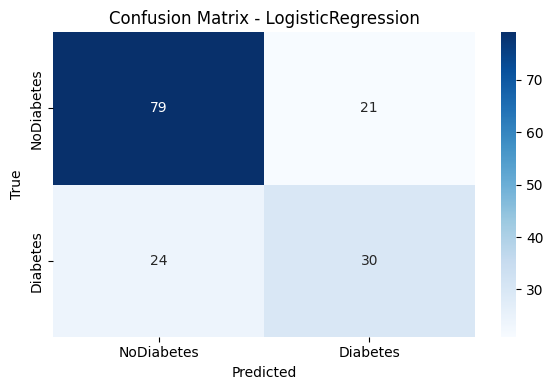

In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_lr = model_lr.predict(X_test_s)
y_proba_lr = model_lr.predict_proba(X_test_s)[:, 1]

evaluations.append(ModelEvaluation(
    model_name="LogisticRegression",
    model=model_lr,
    accuracy=accuracy_score(y_test, y_pred_lr),
    precision=precision_score(y_test, y_pred_lr),
    recall=recall_score(y_test, y_pred_lr),
    f1_score=f1_score(y_test, y_pred_lr),
    y_test=y_test,
    y_pred=y_pred_lr,
    y_proba=y_proba_lr,
))

print(classification_report(y_test, y_pred_lr, target_names=['NoDiabetes', 'Diabetes']))
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NoDiabetes', 'Diabetes'], yticklabels=['NoDiabetes', 'Diabetes'])
plt.title("Confusion Matrix - LogisticRegression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()


## 3.3 Eksperimen

| Kode varian | Preprocessing (fit hanya pada train) | Jumlah fitur |
|---|---|---|
| `baseline_standard` | Median-impute + `StandardScaler` | 8 | 
| `no_scaling` | Median-impute saja (tanpa scaling) | 8 | 
| `minmax` | Median-impute + `MinMaxScaler` | 8 | 
| `robust` | Median-impute + `RobustScaler` (median/IQR) | 8 | 
| `log_standard` | `log1p` pada kolom sangat miring (Insulin skew≈3.0, DiabetesPedigreeFunction skew≈1.9) + Median-impute + `StandardScaler` | 8 | 
| `engineered` | `log1p` seperti di atas + 4 fitur interaksi domain + `StandardScaler` | 12 | 



In [15]:
# Definisi 6 varian preprocessing. Fungsi ini TIDAK me-refit split: ia memakai X_train/X_test
# yang sudah dibuat sebelumnya (80:20, stratify, SEED=42) sehingga semua varian sebanding.
# Imputer & scaler selalu fit-hanya-pada-train (anti data leakage).
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

LOG_COLS = ['Insulin', 'DiabetesPedigreeFunction']  # skew > 1.5 pada EDA

PREPROCESS_VARIANTS = {
    'baseline_standard': 'Median-impute + StandardScaler',
    'no_scaling': 'Median-impute saja, tanpa scaling',
    'minmax': 'Median-impute + MinMaxScaler',
    'robust': 'Median-impute + RobustScaler',
    'log_standard': 'log1p(Insulin, DPF) + Median-impute + StandardScaler',
    'engineered': 'log1p + 4 fitur interaksi + StandardScaler',
}

def add_engineered_features(D: pd.DataFrame) -> pd.DataFrame:
    """Tambah 4 fitur interaksi domain (deterministik, tanpa fitting -> aman dari leakage)."""
    D = D.copy()
    D['Glucose_x_BMI'] = D['Glucose'] * D['BMI'] / 1000.0      # interaksi glukosa-obesitas
    D['Insulin_per_Glucose'] = D['Insulin'] / (D['Glucose'] + 1.0)  # proksi resistansi insulin
    D['Age_x_Pregnancies'] = D['Age'] * (D['Pregnancies'] + 1)  # paritas × usia
    D['Glucose_squared'] = (D['Glucose'] / 100.0) ** 2          # non-linearitas glukosa
    return D

def build_preprocessed(variant: str, X_tr: pd.DataFrame, X_te: pd.DataFrame):
    """Kembalikan (Xtr_arr, Xte_arr, feature_names) untuk satu varian."""
    imp = SimpleImputer(strategy='median')
    Xtr_i = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    Xte_i = pd.DataFrame(imp.transform(X_te), columns=X_te.columns, index=X_te.index)

    # 2) Log-transform kolom miring (sebelum scaling)
    if variant in ('log_standard', 'engineered'):
        for c in LOG_COLS:
            Xtr_i[c] = np.log1p(Xtr_i[c])
            Xte_i[c] = np.log1p(Xte_i[c])

    # 3) Feature engineering (hanya varian engineered)
    if variant == 'engineered':
        Xtr_i = add_engineered_features(Xtr_i)
        Xte_i = add_engineered_features(Xte_i)

    # 4) Scaling (fit pada train saja)
    if variant in ('baseline_standard', 'log_standard', 'engineered'):
        sc = StandardScaler()
    elif variant == 'minmax':
        sc = MinMaxScaler()
    elif variant == 'robust':
        sc = RobustScaler()
    elif variant == 'no_scaling':
        return Xtr_i.values, Xte_i.values, list(Xtr_i.columns)
    else:
        raise ValueError(f'Varian tak dikenal: {variant}')

    Xtr_s = sc.fit_transform(Xtr_i)
    Xte_s = sc.transform(Xte_i)
    return Xtr_s, Xte_s, list(Xtr_i.columns)

print('Varian yang akan diuji:')
for k, desc in PREPROCESS_VARIANTS.items():
    print(f' - {k}: {desc}')


Varian yang akan diuji:
 - baseline_standard: Median-impute + StandardScaler
 - no_scaling: Median-impute saja, tanpa scaling
 - minmax: Median-impute + MinMaxScaler
 - robust: Median-impute + RobustScaler
 - log_standard: log1p(Insulin, DPF) + Median-impute + StandardScaler
 - engineered: log1p + 4 fitur interaksi + StandardScaler


In [16]:
# Experiment loop
from dataclasses import dataclass
from typing import Any
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

@dataclass
class PreprocEvaluation:
    model: str          # 'GaussianNB' / 'LogisticRegression'
    preproc: str        # kode varian, mis. 'log_standard'
    accuracy: float
    precision: float
    recall: float
    f1: float
    roc_auc: float
    n_features: int
    y_test: Any = None
    y_pred: Any = None
    y_proba: Any = None

exp_evaluations = []
for variant in PREPROCESS_VARIANTS:
    Xtr, Xte, feat_names = build_preprocessed(variant, X_train, X_test)
    print(f'\n=== Preprocessing: {variant} ({len(feat_names)} fitur) ===')
    for model_name, model in [
        ('GaussianNB', GaussianNB()),
        ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=cfg.SEED)),
    ]:
        model.fit(Xtr, y_train)
        y_p = model.predict(Xte)
        y_pr = model.predict_proba(Xte)[:, 1]
        ev = PreprocEvaluation(
            model=model_name, preproc=variant,
            accuracy=accuracy_score(y_test, y_p),
            precision=precision_score(y_test, y_p),
            recall=recall_score(y_test, y_p),
            f1=f1_score(y_test, y_p),
            roc_auc=roc_auc_score(y_test, y_pr),
            n_features=len(feat_names),
            y_test=y_test, y_pred=y_p, y_proba=y_pr,
        )
        exp_evaluations.append(ev)
        print(f'{model_name:18s} acc={ev.accuracy:.4f} prec={ev.precision:.4f} '
              f'rec={ev.recall:.4f} f1={ev.f1:.4f} auc={ev.roc_auc:.4f}')

print(f'\nTotal kombinasi tersimpan: {len(exp_evaluations)} (harusnya 12)')



=== Preprocessing: baseline_standard (8 fitur) ===
GaussianNB         acc=0.7273 prec=0.6034 rec=0.6481 f1=0.6250 auc=0.8017
LogisticRegression acc=0.7078 prec=0.5882 rec=0.5556 f1=0.5714 auc=0.8263

=== Preprocessing: no_scaling (8 fitur) ===
GaussianNB         acc=0.7273 prec=0.6034 rec=0.6481 f1=0.6250 auc=0.8017
LogisticRegression acc=0.7078 prec=0.5882 rec=0.5556 f1=0.5714 auc=0.8263

=== Preprocessing: minmax (8 fitur) ===
GaussianNB         acc=0.7273 prec=0.6034 rec=0.6481 f1=0.6250 auc=0.8017
LogisticRegression acc=0.7338 prec=0.6444 rec=0.5370 f1=0.5859 auc=0.8198

=== Preprocessing: robust (8 fitur) ===
GaussianNB         acc=0.7273 prec=0.6034 rec=0.6481 f1=0.6250 auc=0.8017
LogisticRegression acc=0.7078 prec=0.5882 rec=0.5556 f1=0.5714 auc=0.8261

=== Preprocessing: log_standard (8 fitur) ===
GaussianNB         acc=0.7403 prec=0.6250 rec=0.6481 f1=0.6364 auc=0.8331
LogisticRegression acc=0.7403 prec=0.6296 rec=0.6296 f1=0.6296 auc=0.8369

=== Preprocessing: engineered (12

# 4. Evaluasi Model

## 4.1. Baseline Evaluation

,Model,Accuracy,Precision,Recall,F1
0,GaussianNB,0.7273,0.6034,0.6481,0.6250
1,LogisticRegression,0.7078,0.5882,0.5556,0.5714


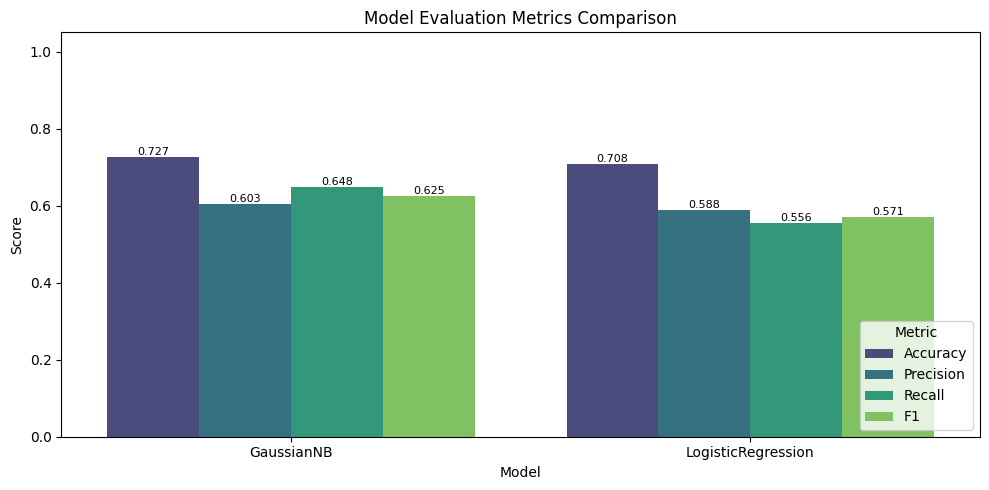

In [17]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
results_df = pd.DataFrame([{
    'Model': e.model_name,
    'Accuracy': e.accuracy,
    'Precision': e.precision,
    'Recall': e.recall,
    'F1': e.f1_score,
} for e in evaluations])
display(results_df.style.format("{:.4f}", subset=['Accuracy', 'Precision', 'Recall', 'F1']))

plot_df = results_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
plt.title("Model Evaluation Metrics Comparison")
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='viridis')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=8)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.legend(title='Metric', loc='lower right')
plt.tight_layout()


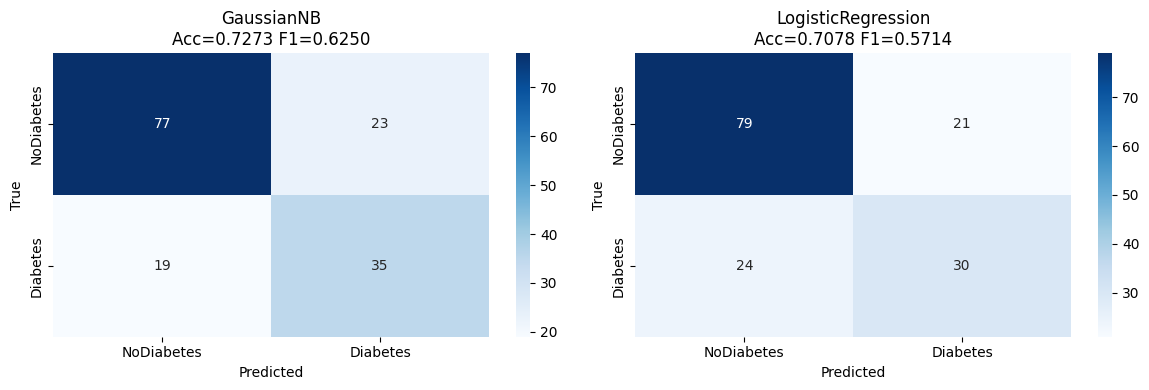

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, len(evaluations), figsize=(6 * len(evaluations), 4))
axes = np.atleast_1d(axes)
for ax, e in zip(axes, evaluations):
    cm = confusion_matrix(e.y_test, e.y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NoDiabetes', 'Diabetes'],
                yticklabels=['NoDiabetes', 'Diabetes'], ax=ax)
    ax.set_title(f"{e.model_name}\nAcc={e.accuracy:.4f} F1={e.f1_score:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()


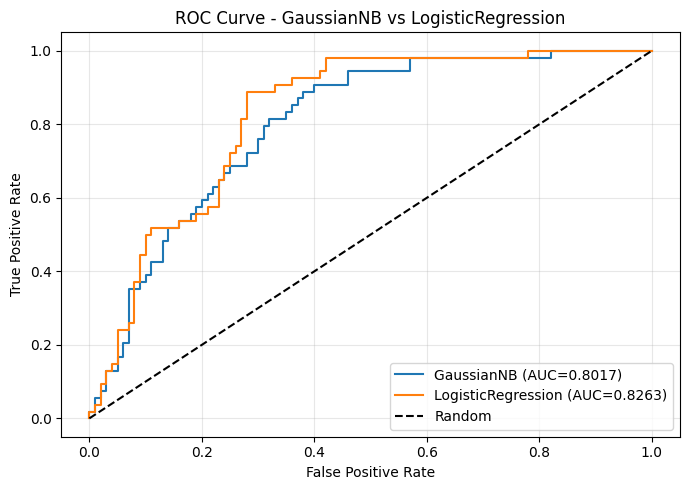

In [19]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7, 5))
for e in evaluations:
    fpr, tpr, _ = roc_curve(e.y_test, e.y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{e.model_name} (AUC={roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title("ROC Curve - GaussianNB vs LogisticRegression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()


,Feature,Coefficient
2,BloodPressure,-0.0042
7,Age,0.1598
6,DiabetesPedigreeFunction,0.1747
3,SkinThickness,0.2950
0,Pregnancies,0.3372
5,BMI,0.4661
4,Insulin,0.6142
1,Glucose,0.9349


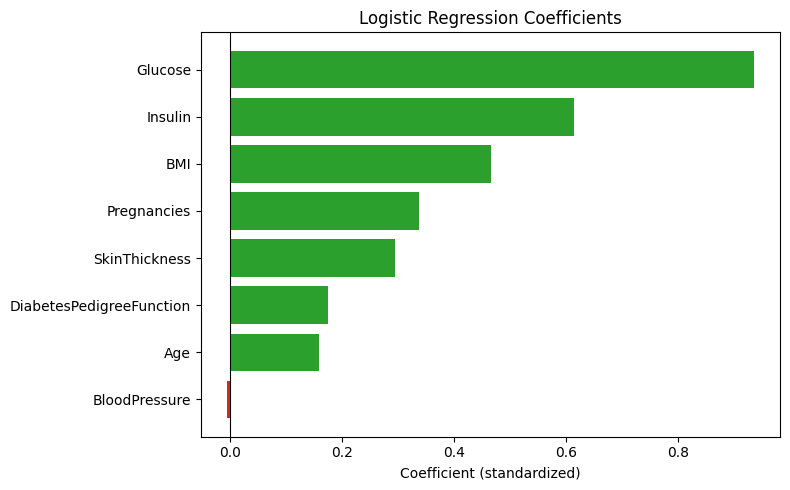

In [ ]:

# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
# Koefisien dibaca pada skala terstandarisasi (setelah StandardScaler) sehingga besarnya sebanding antar fitur.
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_lr.coef_[0]}).sort_values('Coefficient')

plt.figure(figsize=(8, 5))
plt.title("Logistic Regression Coefficients")
colors = ['tab:red' if v < 0 else 'tab:green' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Coefficient (standardized)")
plt.tight_layout()
display(coef_df.style.format("{:.4f}", subset=['Coefficient']))


## 4.2. Comparison


,Model,Preprocessing,N_Fitur,Accuracy,Precision,Recall,F1,AUC
10,GaussianNB,engineered,12,0.7403,0.6207,0.6667,0.6429,0.8094
8,GaussianNB,log_standard,8,0.7403,0.6250,0.6481,0.6364,0.8331
0,GaussianNB,baseline_standard,8,0.7273,0.6034,0.6481,0.6250,0.8017
2,GaussianNB,no_scaling,8,0.7273,0.6034,0.6481,0.6250,0.8017
4,GaussianNB,minmax,8,0.7273,0.6034,0.6481,0.6250,0.8017
6,GaussianNB,robust,8,0.7273,0.6034,0.6481,0.6250,0.8017
11,LogisticRegression,engineered,12,0.7597,0.6809,0.5926,0.6337,0.8402
9,LogisticRegression,log_standard,8,0.7403,0.6296,0.6296,0.6296,0.8369
5,LogisticRegression,minmax,8,0.7338,0.6444,0.5370,0.5859,0.8198
1,LogisticRegression,baseline_standard,8,0.7078,0.5882,0.5556,0.5714,0.8263


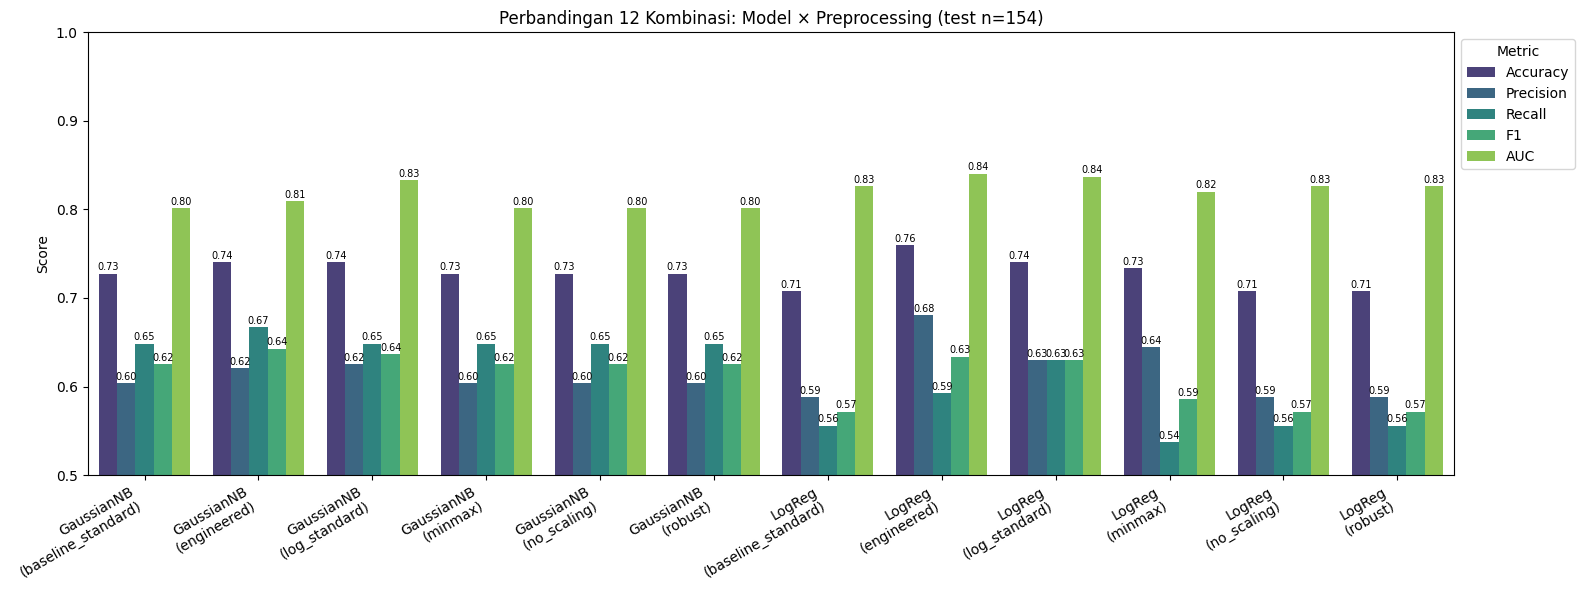

,Model,Preprocessing,Accuracy,F1,AUC,d_Accuracy,d_F1,d_AUC
10,GaussianNB,engineered,0.7403,0.6429,0.8094,+0.0130,+0.0179,+0.0078
8,GaussianNB,log_standard,0.7403,0.6364,0.8331,+0.0130,+0.0114,+0.0315
0,GaussianNB,baseline_standard,0.7273,0.6250,0.8017,+0.0000,+0.0000,+0.0000
2,GaussianNB,no_scaling,0.7273,0.6250,0.8017,+0.0000,+0.0000,+0.0000
4,GaussianNB,minmax,0.7273,0.6250,0.8017,+0.0000,+0.0000,+0.0000
6,GaussianNB,robust,0.7273,0.6250,0.8017,+0.0000,+0.0000,+0.0000
11,LogisticRegression,engineered,0.7597,0.6337,0.8402,+0.0519,+0.0622,+0.0139
9,LogisticRegression,log_standard,0.7403,0.6296,0.8369,+0.0325,+0.0582,+0.0106
5,LogisticRegression,minmax,0.7338,0.5859,0.8198,+0.0260,+0.0144,-0.0065
1,LogisticRegression,baseline_standard,0.7078,0.5714,0.8263,+0.0000,+0.0000,+0.0000


In [ ]:
exp_df = pd.DataFrame([{
    'Model': e.model,
    'Preprocessing': e.preproc,
    'N_Fitur': e.n_features,
    'Accuracy': e.accuracy,
    'Precision': e.precision,
    'Recall': e.recall,
    'F1': e.f1,
    'AUC': e.roc_auc,
} for e in exp_evaluations])

display(exp_df.sort_values(['Model', 'F1'], ascending=[True, False])
        .style.format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
                       'Recall': '{:.4f}', 'F1': '{:.4f}', 'AUC': '{:.4f}'}))

# Barplot, hue = Metric
plot_df = exp_df.melt(id_vars=['Model', 'Preprocessing'],
                      value_vars=['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
                      var_name='Metric', value_name='Score')
plot_df['Label'] = plot_df['Model'].str.replace('LogisticRegression', 'LogReg') + '\n(' + plot_df['Preprocessing'] + ')'
order = exp_df.copy()
order['Label'] = order['Model'].str.replace('LogisticRegression', 'LogReg') + '\n(' + order['Preprocessing'] + ')'
order = order.sort_values(['Model', 'Preprocessing'])['Label'].tolist()

plt.figure(figsize=(16, 6))
ax = sns.barplot(data=plot_df, x='Label', y='Score', hue='Metric', palette='viridis', order=order)
ax.set_title('Perbandingan 12 Kombinasi: Model × Preprocessing (test n=154)')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim(0.5, 1.0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=1)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Tabel delta vs baseline (baseline_standard) per model — untuk bahan analisis §5.
base = exp_df[exp_df['Preprocessing'] == 'baseline_standard'].set_index('Model')
delta = exp_df.copy()
for m in ['Accuracy', 'F1', 'AUC']:
    delta[f'd_{m}'] = delta.apply(lambda r: r[m] - base.loc[r['Model'], m], axis=1)
display(delta[['Model', 'Preprocessing', 'Accuracy', 'F1', 'AUC', 'd_Accuracy', 'd_F1', 'd_AUC']]
        .sort_values(['Model', 'F1'], ascending=[True, False])
        .style.format({'Accuracy': '{:.4f}', 'F1': '{:.4f}', 'AUC': '{:.4f}',
                       'd_Accuracy': '{:+.4f}', 'd_F1': '{:+.4f}', 'd_AUC': '{:+.4f}'}))


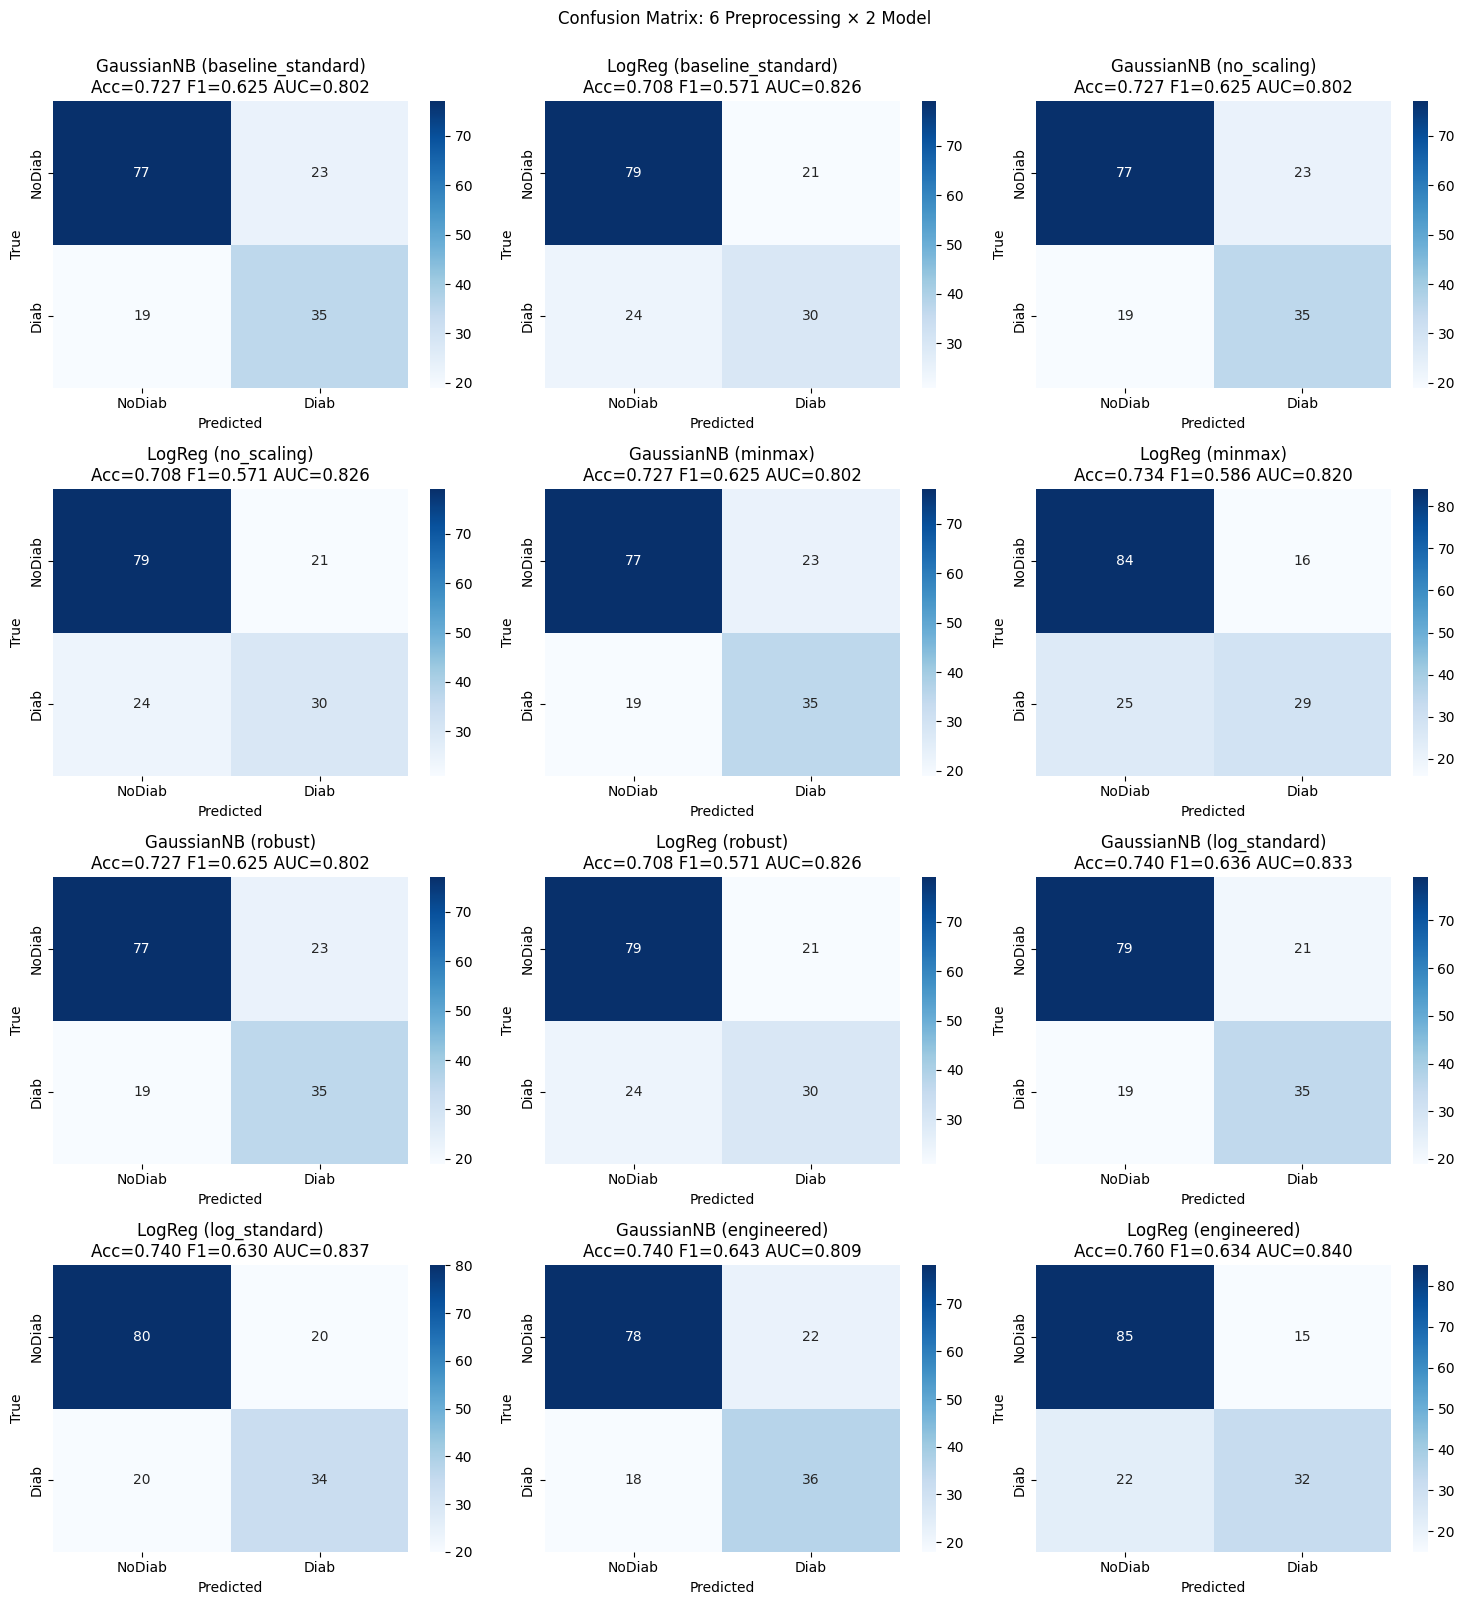

In [22]:
# Grid confusion matrix 12 kombinasi (6 varian × 2 model), sejajar dengan grid 9 CM di Notebook 1.
# Memakai y_test/y_pred tersimpan (tanpa predict ulang) agar tidak tertukar transformasi.
import math
n_cols = 3
n_rows = math.ceil(len(exp_evaluations) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).ravel()
for ax, e in zip(axes, exp_evaluations):
    cm = confusion_matrix(e.y_test, e.y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NoDiab', 'Diab'], yticklabels=['NoDiab', 'Diab'], ax=ax)
    ax.set_title(f"{e.model.replace('LogisticRegression','LogReg')} ({e.preproc})\nAcc={e.accuracy:.3f} F1={e.f1:.3f} AUC={e.roc_auc:.3f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
for ax in axes[len(exp_evaluations):]:
    ax.axis('off')
plt.suptitle('Confusion Matrix: 6 Preprocessing × 2 Model', y=1.0)
plt.tight_layout()
plt.show()


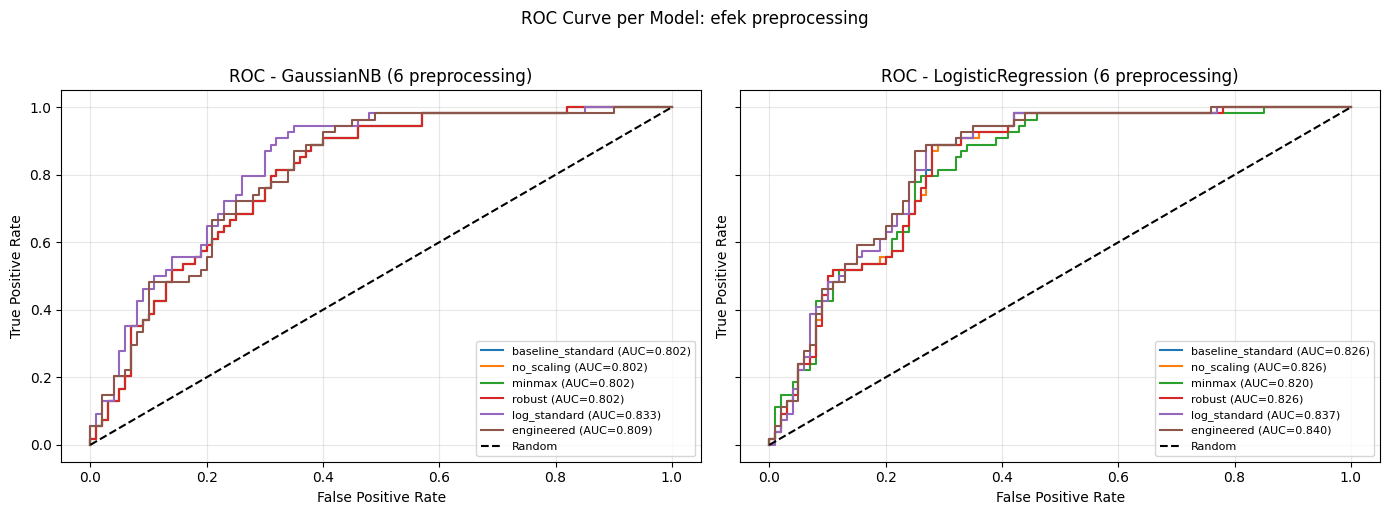

In [ ]:
# ROC per model
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, model_name in zip(np.atleast_1d(axes), ['GaussianNB', 'LogisticRegression']):
    for e in [ev for ev in exp_evaluations if ev.model == model_name]:
        fpr, tpr, _ = roc_curve(e.y_test, e.y_proba)
        ax.plot(fpr, tpr, label=f"{e.preproc} (AUC={e.roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_title(f'ROC - {model_name} (6 preprocessing)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('ROC Curve per Model: efek preprocessing', y=1.02)
plt.tight_layout()
plt.show()


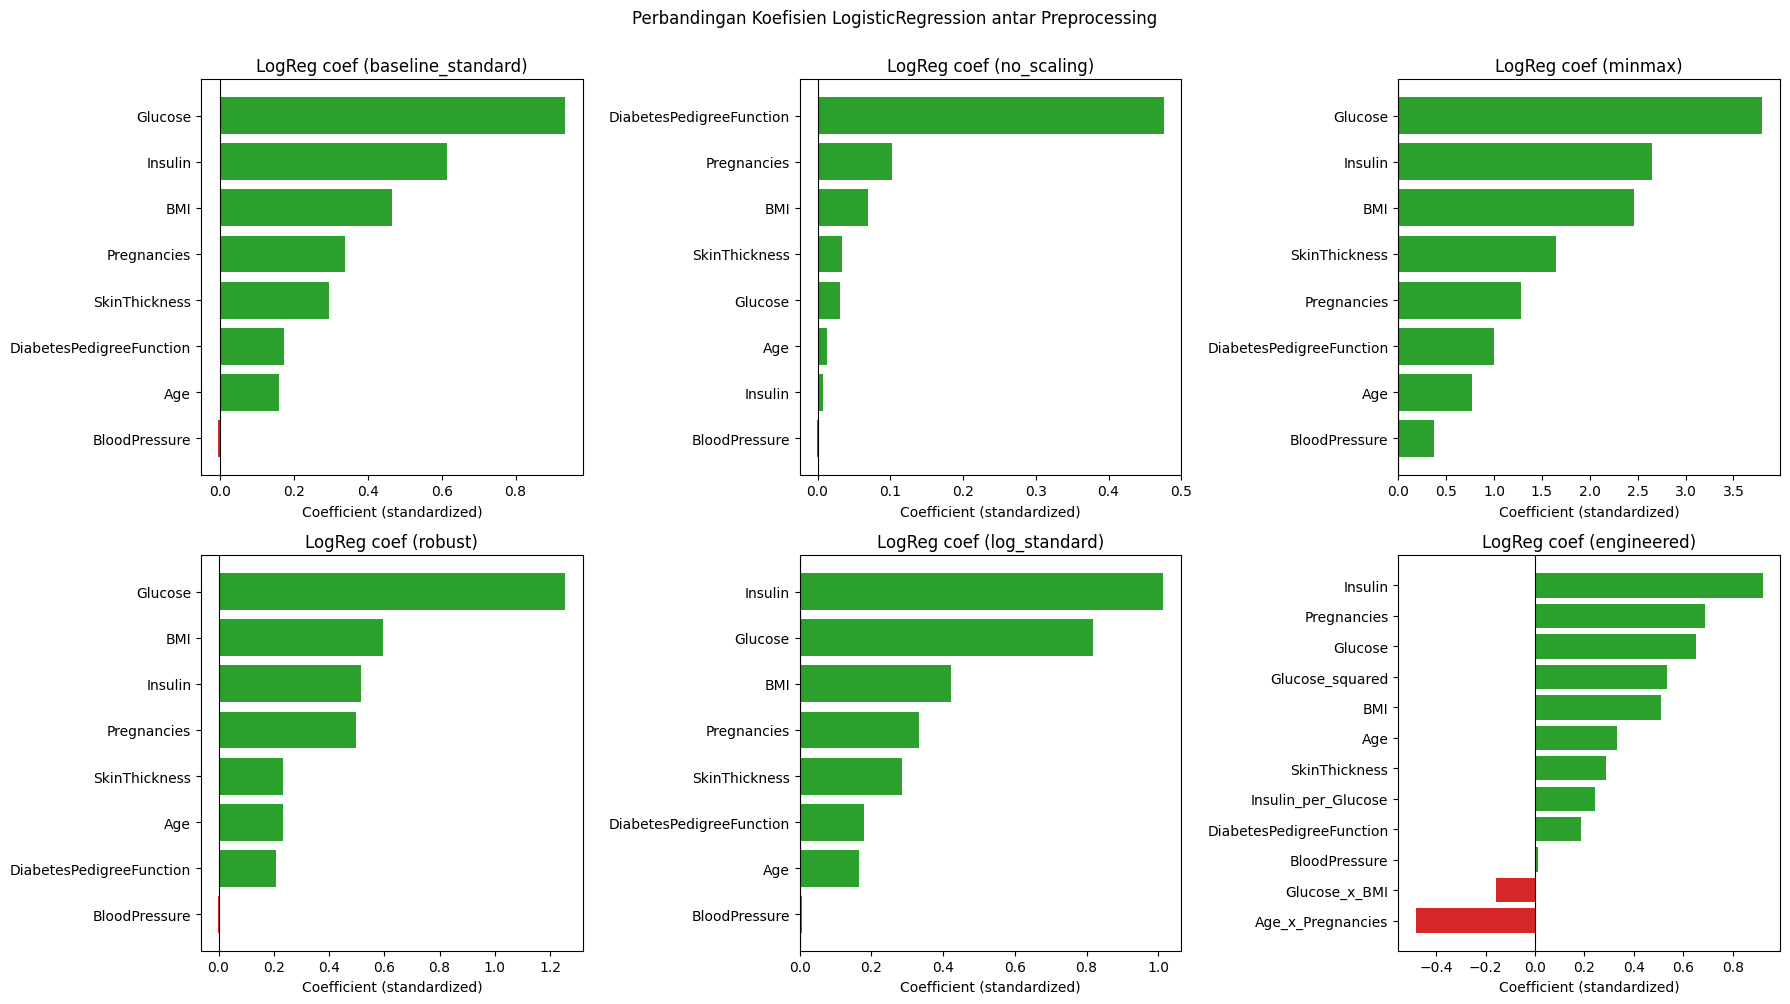

In [ ]:
# Koefisien LogisticRegression per varian
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = np.array(axes).ravel()
# Rekonstruksi ulang koefisien per varian dengan fit pada train (deterministik, seed sama)
for ax, variant in zip(axes, list(PREPROCESS_VARIANTS.keys())):
    Xtr, Xte, feat_names = build_preprocessed(variant, X_train, X_test)
    lr = LogisticRegression(max_iter=1000, random_state=cfg.SEED).fit(Xtr, y_train)
    order = np.argsort(lr.coef_[0])
    colors = ['tab:red' if v < 0 else 'tab:green' for v in lr.coef_[0][order]]
    ax.barh(np.array(feat_names)[order], lr.coef_[0][order], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'LogReg coef ({variant})')
    ax.set_xlabel('Coefficient (standardized)')
plt.suptitle('Perbandingan Koefisien LogisticRegression antar Preprocessing', y=1.0)
plt.tight_layout()
plt.show()


# 5. Analisis

#### 5.1 Ringkasan hasil eksperimen

Hasil 12 kombinasi (6 preprocessing × 2 model) pada split test yang identik (n=154; 100 NoDiabetes, 54 Diabetes):

| Model | Preprocessing | N_Fitur | Akurasi | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|---|---|
| GaussianNB | baseline_standard | 8 | 0.7273 | 0.6034 | 0.6481 | 0.6250 | 0.8017 |
| GaussianNB | no_scaling | 8 | 0.7273 | 0.6034 | 0.6481 | 0.6250 | 0.8017 |
| GaussianNB | minmax | 8 | 0.7273 | 0.6034 | 0.6481 | 0.6250 | 0.8017 |
| GaussianNB | robust | 8 | 0.7273 | 0.6034 | 0.6481 | 0.6250 | 0.8017 |
| GaussianNB | log_standard | 8 | 0.7403 | 0.6250 | 0.6481 | 0.6364 | 0.8331 |
| GaussianNB | engineered | 12 | 0.7403 | 0.6207 | 0.6667 | 0.6429 | 0.8094 |
| LogisticRegression | baseline_standard | 8 | 0.7078 | 0.5882 | 0.5556 | 0.5714 | 0.8263 |
| LogisticRegression | no_scaling | 8 | 0.7078 | 0.5882 | 0.5556 | 0.5714 | 0.8261 |
| LogisticRegression | robust | 8 | 0.7078 | 0.5882 | 0.5556 | 0.5714 | 0.8261 |
| LogisticRegression | minmax | 8 | 0.7338 | 0.6444 | 0.5370 | 0.5859 | 0.8198 |
| LogisticRegression | log_standard | 8 | 0.7403 | 0.6296 | 0.6296 | 0.6296 | 0.8369 |
| LogisticRegression | engineered | 12 | 0.7597 | 0.6809 | 0.5926 | 0.6337 | 0.8402 |

Delta terhadap baseline masing-masing model (tabel `d_Accuracy/d_F1/d_AUC` pada 4B):

| Model | Varian | d_Acc | d_F1 | d_AUC |
|---|---|---|---|---|
| GNB | log_standard | +0.0130 | +0.0114 | +0.0315 |
| GNB | engineered | +0.0130 | +0.0179 | +0.0078 |
| LogReg | minmax | +0.0260 | +0.0144 | -0.0065 |
| LogReg | log_standard | +0.0325 | +0.0582 | +0.0106 |
| LogReg | engineered | +0.0519 | +0.0622 | +0.0139 |

Confusion matrix (TN=NoDiabetes benar, FP=NoDiabetes dikira diabetes, FN=diabetes lolos, TP=diabetes benar):

| Model (varian) | TN | FP | FN | TP |
|---|---|---|---|---|
| GNB (baseline) | 77 | 23 | 19 | 35 |
| GNB (log_standard) | 79 | 21 | 19 | 35 |
| GNB (engineered) | 78 | 22 | 18 | 36 |
| LogReg (baseline) | 79 | 21 | 24 | 30 |
| LogReg (minmax) | 84 | 16 | 25 | 29 |
| LogReg (log_standard) | 80 | 20 | 20 | 34 |
| LogReg (engineered) | 85 | 15 | 22 | 32 |

Berbeda dengan Notebook 1 (varian `drop` mengubah ukuran test 1625→1129 sehingga tidak sebanding), di sini **semua 12 kombinasi dievaluasi pada test set yang persis sama**, sehingga selisih angka murni efek preprocessing.

#### 5.2 Pengaruh scaling: GNB invarian, LogReg sensitif

**1. Empat varian scaling menghasilkan skor GNB yang identik persis (0.7273/0.6250/0.8017).**
Ini hasil yang diharapkan secara teori, bukan kebetulan. GaussianNB hanya memakai mean dan varians per fitur per kelas; transformasi linear $x'=(x-\mu)/\sigma$ (Standard), $x'=(x-\min)/(\max-\min)$ (MinMax), atau $(x-median)/IQR$ (Robust) menggeser mean/varians train dan test secara konsisten sehingga likelihood relatif antar kelas tidak berubah (di luar efek numerik `var_smoothing`). Sel `no_scaling` membuktikan hal yang sama: tanpa scaler pun GNB mendapat angka identik. Kesimpulan metodologisnya: untuk GNB, tuning scaler adalah usaha yang sia-sia; yang mengubah performa hanyalah transformasi non-linear atau fitur baru.

**2. LogReg justru sensitif terhadap scaling, tetapi tidak semua scaler membantu.**
`no_scaling` ≈ `robust` ≈ `baseline` (0.7078/0.5714), sedangkan `minmax` menaikkan akurasi +2.6 poin (0.7338) dan precision +5.6 poin (0.6444) tetapi **menurunkan recall** (0.5370 vs 0.5556, FN 25 vs 24) dan AUC (-0.0065). Artinya MinMax membuat model lebih konservatif memprediksi diabetes (FP turun 21→16, TN naik 79→84) dengan harga lebih banyak kasus diabetes lolos. Ini konsisten dengan sifat MinMax yang memampatkan rentang 0–1 berdasarkan min–max train sehingga outlier (Insulin 846, SkinThickness 99) memampatkan mayoritas data ke pita sempit dan menggeser threshold efektif 0.5. `robust` yang memakai median/IQR praktis identik dengan Standard di sini karena data versi ini sudah bersih (tidak ada nol mustahil), sehingga outlier tersisa tidak cukup ekstrem untuk membedakan keduanya.

**3. Perbandingan koefisien antar scaler tidak valid secara langsung.**
Pada skala terstandarisasi (4, baseline) urutannya Glucose +0.935 > Insulin +0.614 > BMI +0.466; pada MinMax angkanya menggembung (Glucose +3.80, Insulin +2.65) karena satuan fiturnya berbeda. Koefisien hanya sebanding **di dalam satu varian**, bukan antar varian — kesalahan umum yang dihindari dengan membaca tiap subplot 4B secara terpisah.

#### 5.3 Pengaruh log-transform dan feature engineering: satu-satunya peningkatan yang konsisten

**1. `log1p` pada Insulin dan DiabetesPedigreeFunction memperbaiki kedua model.**
Kedua kolom ini adalah yang paling miring pada EDA (Insulin skew≈3.0, DPF skew≈1.9, ekor sampai 846 dan 2.42). Setelah `log1p`, GNB naik +1.3 poin akurasi dan +3.2 poin AUC (0.8017→0.8331, FP 23→21); LogReg naik +3.3 poin akurasi dan +5.8 poin F1 (0.5714→0.6296, FN 24→20, seimbang 20/20). Ini konsisten dengan asumsi model: GNB mengasumsikan Gaussian per kelas sehingga ekor panjang melanggar asumsi; LogReg mengasumsikan log-odds linear sehingga skala logaritmik lebih linear terhadap risiko. Urutan koefisien LogReg ikut berubah secara informatif: Insulin menjadi dominan (+1.014) melewati Glucose (+0.818), artinya setelah kompresi ekor, sinyal insulin terbaca lebih bersih.

**2. `engineered` (log + 4 fitur interaksi) adalah varian terbaik untuk kedua model, terutama LogReg.**
GNB engineered mencapai F1 tertinggi di antara semua varian GNB (0.6429, recall 0.6667, TP 36) sedangkan LogReg engineered mencetak skor terbaik global (akurasi 0.7597, precision 0.6809, F1 0.6337, AUC 0.8402; TN 85, FP hanya 15). Kenaikan LogReg vs baseline (+5.2 poin akurasi, +6.2 poin F1) jauh lebih besar daripada kenaikan GNB (+1.3/+1.8), yang wajar: fitur interaksi (`Glucose_x_BMI`, `Insulin_per_Glucose`, `Age_x_Pregnancies`, `Glucose_squared`) memberi LogReg batas keputusan yang secara efektif non-linear di ruang asal tanpa mengganti modelnya, sedangkan GNB yang mengasumsikan independensi antar fitur justru terbebani korelasi tambahan (AUC-nya 0.8094, lebih rendah dari versi `log_standard` 0.8331 — ranking memburuk meski keputusan threshold-nya membaik).

**3. Catatan kehati-hatian pada koefisien engineered.**
Koefisien terbesar tetap masuk akal (Insulin +0.92, Pregnancies +0.69, Glucose +0.65), tetapi `Age_x_Pregnancies` bernilai negatif (-0.48) dan `Glucose_x_BMI` negatif (-0.16) walaupun korelasi marginalnya positif. Ini artefak multikolinearitas: `Age_x_Pregnancies` berkorelasi kuat dengan `Age` dan `Pregnancies` sehingga LogReg mendistribusikan bobot secara meniadakan (cancellation). Jangan dibaca sebagai "semakin tua × banyak anak semakin rendah risiko" — baca gabungan ketiganya, atau gunakan regularisasi/seleksi fitur bila interpretasi kausal dibutuhkan.

#### 5.4 Perbandingan GNB vs Logistic Regression dan kaitan dengan EDA

**1. Setelah preprocessing terbaik, LogReg menyalip GNB — kebalikan dari kesimpulan baseline.**
Pada baseline (3–4) GNB menang tipis (0.7273 vs 0.7078, F1 0.6250 vs 0.5714) tetapi AUC LogReg sudah lebih tinggi (0.8263 vs 0.8017). Setelah `engineered`, LogReg unggul di **semua** metrik kecuali recall (akurasi 0.7597 vs 0.7403, F1 0.6337 vs 0.6429 hampir setara, AUC 0.8402 vs 0.8094). Pelajarannya: perbandingan model tanpa feature engineering yang memadai bersifat prematur; GNB lebih robust pada representasi mentah, LogReg lebih diuntungkan representasi yang baik.

**2. Kedua model tetap kesulitan pada kelas diabetes (minoritas 34.9%).**
Bahkan pada varian terbaik, precision diabetes hanya 0.62–0.68 dan recall 0.59–0.67: ~1 dari 3 prediksi diabetes adalah false alarm, dan ~1 dari 3 pasien diabetes lolos (FN 18–22). Untuk konteks medis, FN jauh lebih berbahaya daripada FP — `engineered` LogReg (FP 15, FN 22) vs GNB engineered (FP 22, FN 18) menunjukkan trade-off yang harus dipilih eksplisit via threshold, bukan dibiarkan pada default 0.5.

**3. Kaitan dengan EDA dan kebersihan data.**
- Urutan sinyal EDA terkonfirmasi: korelasi Outcome tertinggi Glucose (0.50) → koefisien baseline terbesar Glucose (+0.935); selisih rata-rata per kelas terbesar juga pada Glucose/Insulin/BMI — model bertumpu pada sinyal yang sama.
- File `diabetes.csv` versi ini sudah bersih (0 missing, 0 duplikat, 0 nol mustahil; median berulang seperti Insulin=102.5 menandakan imputasi di hulu), sehingga pipeline 0→NaN + `SimpleImputer(median)` menjadi no-op yang tetap benar.
- Tidak ada leakage: imputer dan semua scaler di-fit hanya pada train (614) lalu diterapkan ke test (154); split `stratify` menjaga proporsi 65:35 identik; semua varian memakai split yang sama sehingga perbandingan adil (keunggulan 4B atas pola Notebook 1 yang test-nya berubah pada varian `drop`).


# 6. Kesimpulan dan Saran

#### 6.1 Kesimpulan

1. **Preprocessing terbaik adalah `engineered` (log + 4 fitur interaksi + StandardScaler): LogisticRegression mencapai skor tertinggi global** (akurasi 0.7597, precision 0.6809, F1 0.6337, AUC 0.8402; TN/FP/FN/TP = 85/15/22/32), naik +5.2 poin akurasi dan +6.2 poin F1 dari baseline. GaussianNB terbaiknya juga pada `engineered`/`log_standard` (0.7403, F1 0.6429/0.6364), tetapi tidak setinggi LogReg.
2. **Scaling linear tidak berpengaruh pada GaussianNB (empat varian identik 0.7273/0.6250/0.8017) tetapi berpengaruh pada LogisticRegression.** MinMax menaikkan akurasi (+2.6 poin) dengan harga recall turun; Robust ≈ Standard pada data yang sudah bersih ini. Koefisien hanya dapat dibandingkan di dalam satu varian, bukan antar scaler.
3. **`log1p` pada Insulin/DPF adalah perbaikan termurah dan paling konsisten** (+1.3 poin akurasi GNB dengan +3.2 poin AUC; +3.3 poin akurasi dan +5.8 poin F1 LogReg) karena menangani skew 3.0/1.9 yang melanggar asumsi Gaussian dan linearitas. Setelah transformasi, Insulin menjadi fitur dominan LogReg (+1.014 > Glucose +0.818).
4. **Kesimpulan baseline ("GNB menang tipis") berbalik setelah feature engineering:** GNB lebih robust pada representasi mentah, LogReg lebih diuntungkan representasi yang baik dan akhirnya unggul di akurasi, precision, dan AUC. Keduanya tetap moderat (~0.74–0.76) karena sinyal tumpang tindih, imbalance 34.9%, dan error terkonsentrasi pada kelas diabetes — belum aman untuk skrining mentah (FN 18–22 pada varian terbaik).

#### 6.2 Saran

1. **Threshold tuning / cost-sensitive learning (mendesak, karena FN mahal):** pilih threshold dari kurva ROC 4B (mis. Youden's J) atau `class_weight='balanced'` agar recall diabetes naik dari ~0.59–0.67; laporkan trade-off FP–FN eksplisit alih-alih default 0.5. Varian `log_standard` LogReg (FP/FN seimbang 20/20) adalah titik awal yang baik.
2. **Validasi lebih ketat:** stratified k-fold cross-validation + interval kepercayaan untuk memastikan selisih 1–5 poin antar 12 kombinasi bukan artefak satu split; pertimbangkan pula PR-AUC dan balanced accuracy yang lebih adil untuk data imbalanced daripada akurasi mentah.
3. **Rapikan feature engineering:** uji ablasi (buang satu per satu dari 4 fitur tambahan), atasi multikolinearitas (`Age_x_Pregnancies` negatif artifisial) via VIF/regularisasi L1/L2 atau `SelectKBest`/PCA, dan coba outlier clipping sebagai alternatif RobustScaler; bandingkan dengan model non-linear (Random Forest, Gradient Boosting) sebagai pembanding atas batas linear.
4. **Kalibrasi probabilitas sebelum dipakai sebagai skor klinis:** cek kurva kalibrasi/reliability untuk LogReg `engineered` (AUC 0.8402 menunjukkan ranking baik, tetapi probabilitasnya belum tentu terkalibrasi), lalu validasi pada data luar/temporal bila tersedia.
